# LeetCode #475: Heaters

https://leetcode.com/problems/heaters/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(m \cdot n)$ | $O(1)$ |
| **Sort + Binary Search** | $O((m + n) \log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
For each house, check every heater and find the minimum distance. Take the max over all houses. $O(m \cdot n)$ — too slow for $m, n = 25000$.

### Optimal: Sort + Binary Search ★
Sort the heaters array. For each house, binary search for the nearest heater (the insertion point gives the two closest candidates — one on each side). The required radius is the distance to the nearer one. The answer is the maximum radius across all houses.

**Why this is better than Brute Force:** Binary search reduces per-house work from $O(n)$ to $O(\log n)$, giving $O((m+n)\log n)$ total.

**Constraints:**
* 1 <= houses.length, heaters.length <= 25000
* 0 <= houses[i], heaters[i] <= 10^9

## Solutions

### C#

In [ ]:
public class Solution {
    public int FindRadius(int[] houses, int[] heaters) {
        Array.Sort(heaters);
        int radius = 0;

        foreach (int house in houses) {
            // Find insertion point of house in sorted heaters
            int pos = Array.BinarySearch(heaters, house);
            if (pos < 0) pos = ~pos;  // bitwise complement gives insertion index

            // Distance to the nearest heater on either side
            int distRight = pos < heaters.Length ? heaters[pos] - house : int.MaxValue;
            int distLeft  = pos > 0 ? house - heaters[pos - 1] : int.MaxValue;
            // Minimum distance is what this house needs
            radius = Math.Max(radius, Math.Min(distLeft, distRight));
        }
        return radius;
    }
}

### Python

In [ ]:
from bisect import bisect_left

class Solution:
    def findRadius(self, houses: list[int], heaters: list[int]) -> int:
        heaters.sort()
        radius = 0

        for house in houses:
            # Find insertion point of house in sorted heaters
            pos = bisect_left(heaters, house)

            # Distance to nearest heater on either side
            dist_right = heaters[pos] - house if pos < len(heaters) else float('inf')
            dist_left  = house - heaters[pos - 1] if pos > 0 else float('inf')
            # Minimum distance is what this house needs
            radius = max(radius, min(dist_left, dist_right))

        return radius

### Go

In [ ]:
func findRadius(houses []int, heaters []int) int {
    sort.Ints(heaters)
    radius := 0

    for _, house := range houses {
        // Find insertion point of house in sorted heaters
        pos := sort.SearchInts(heaters, house)

        // Distance to nearest heater on either side
        distRight := math.MaxInt32
        if pos < len(heaters) {
            distRight = heaters[pos] - house
        }
        distLeft := math.MaxInt32
        if pos > 0 {
            distLeft = house - heaters[pos-1]
        }
        // Minimum distance is what this house needs
        d := distLeft
        if distRight < d { d = distRight }
        if d > radius { radius = d }
    }
    return radius
}

### Rust

In [ ]:
impl Solution {
    pub fn find_radius(houses: Vec<i32>, mut heaters: Vec<i32>) -> i32 {
        heaters.sort();
        let mut radius = 0;

        for house in &houses {
            // Find insertion point of house in sorted heaters
            let pos = heaters.partition_point(|&h| h < *house);

            // Distance to nearest heater on either side
            let dist_right = if pos < heaters.len() {
                heaters[pos] - house
            } else {
                i32::MAX
            };
            let dist_left = if pos > 0 {
                house - heaters[pos - 1]
            } else {
                i32::MAX
            };
            // Minimum distance is what this house needs
            radius = radius.max(dist_left.min(dist_right));
        }
        radius
    }
}

## Example Scenarios

**1. Common Case**
**Input:** houses=[1,2,3], heaters=[2]
Sorted heaters=[2]. For house 1: pos=1, distRight=2-1=1, distLeft=∞ → need 1. For house 2: exact hit, need 0. For house 3: pos=1, distRight=∞, distLeft=3-2=1 → need 1. Max=1.

**2. Slightly Complex**
**Input:** houses=[1,2,3,4], heaters=[1,4]
Sorted heaters=[1,4]. House 2: pos=1, distRight=4-2=2, distLeft=2-1=1 → need 1. House 3: pos=1, distRight=4-3=1, distLeft=3-1=2 → need 1. Max=1.

**3. Edge Case: Time Factor**
**Input:** houses=[0,1,…,24999], heaters=[12499] (single centered heater, n=m=25000)
Every house binary-searches in O(log 1)=O(1). Max distance from heater: max(12499-0, 24999-12499)=12500. Total: O(n log 1 + n) = O(n). Worst-case for linear search (O(m·n) = O(25000)) is O(n log n) for binary search.

**4. Edge Case: Space Factor**
**Input:** houses=[0], heaters=[10^9]
One house, one heater. pos=0, distRight=10^9-0=10^9, distLeft=∞ → need 10^9. Space: O(1) extra (just pos, distLeft, distRight, radius). Sort is in-place.

**5. Almost-Impossible but Plausible**
**Input:** houses=[10^9], heaters=[0]
Sorted heaters=[0]. For house 10^9: pos=1 (insertion after 0), distRight=∞, distLeft=10^9-0=10^9 → return 10^9. The result fits in int (10^9 < INT_MAX≈2.1×10^9). No overflow risk here since distances are at most 10^9.

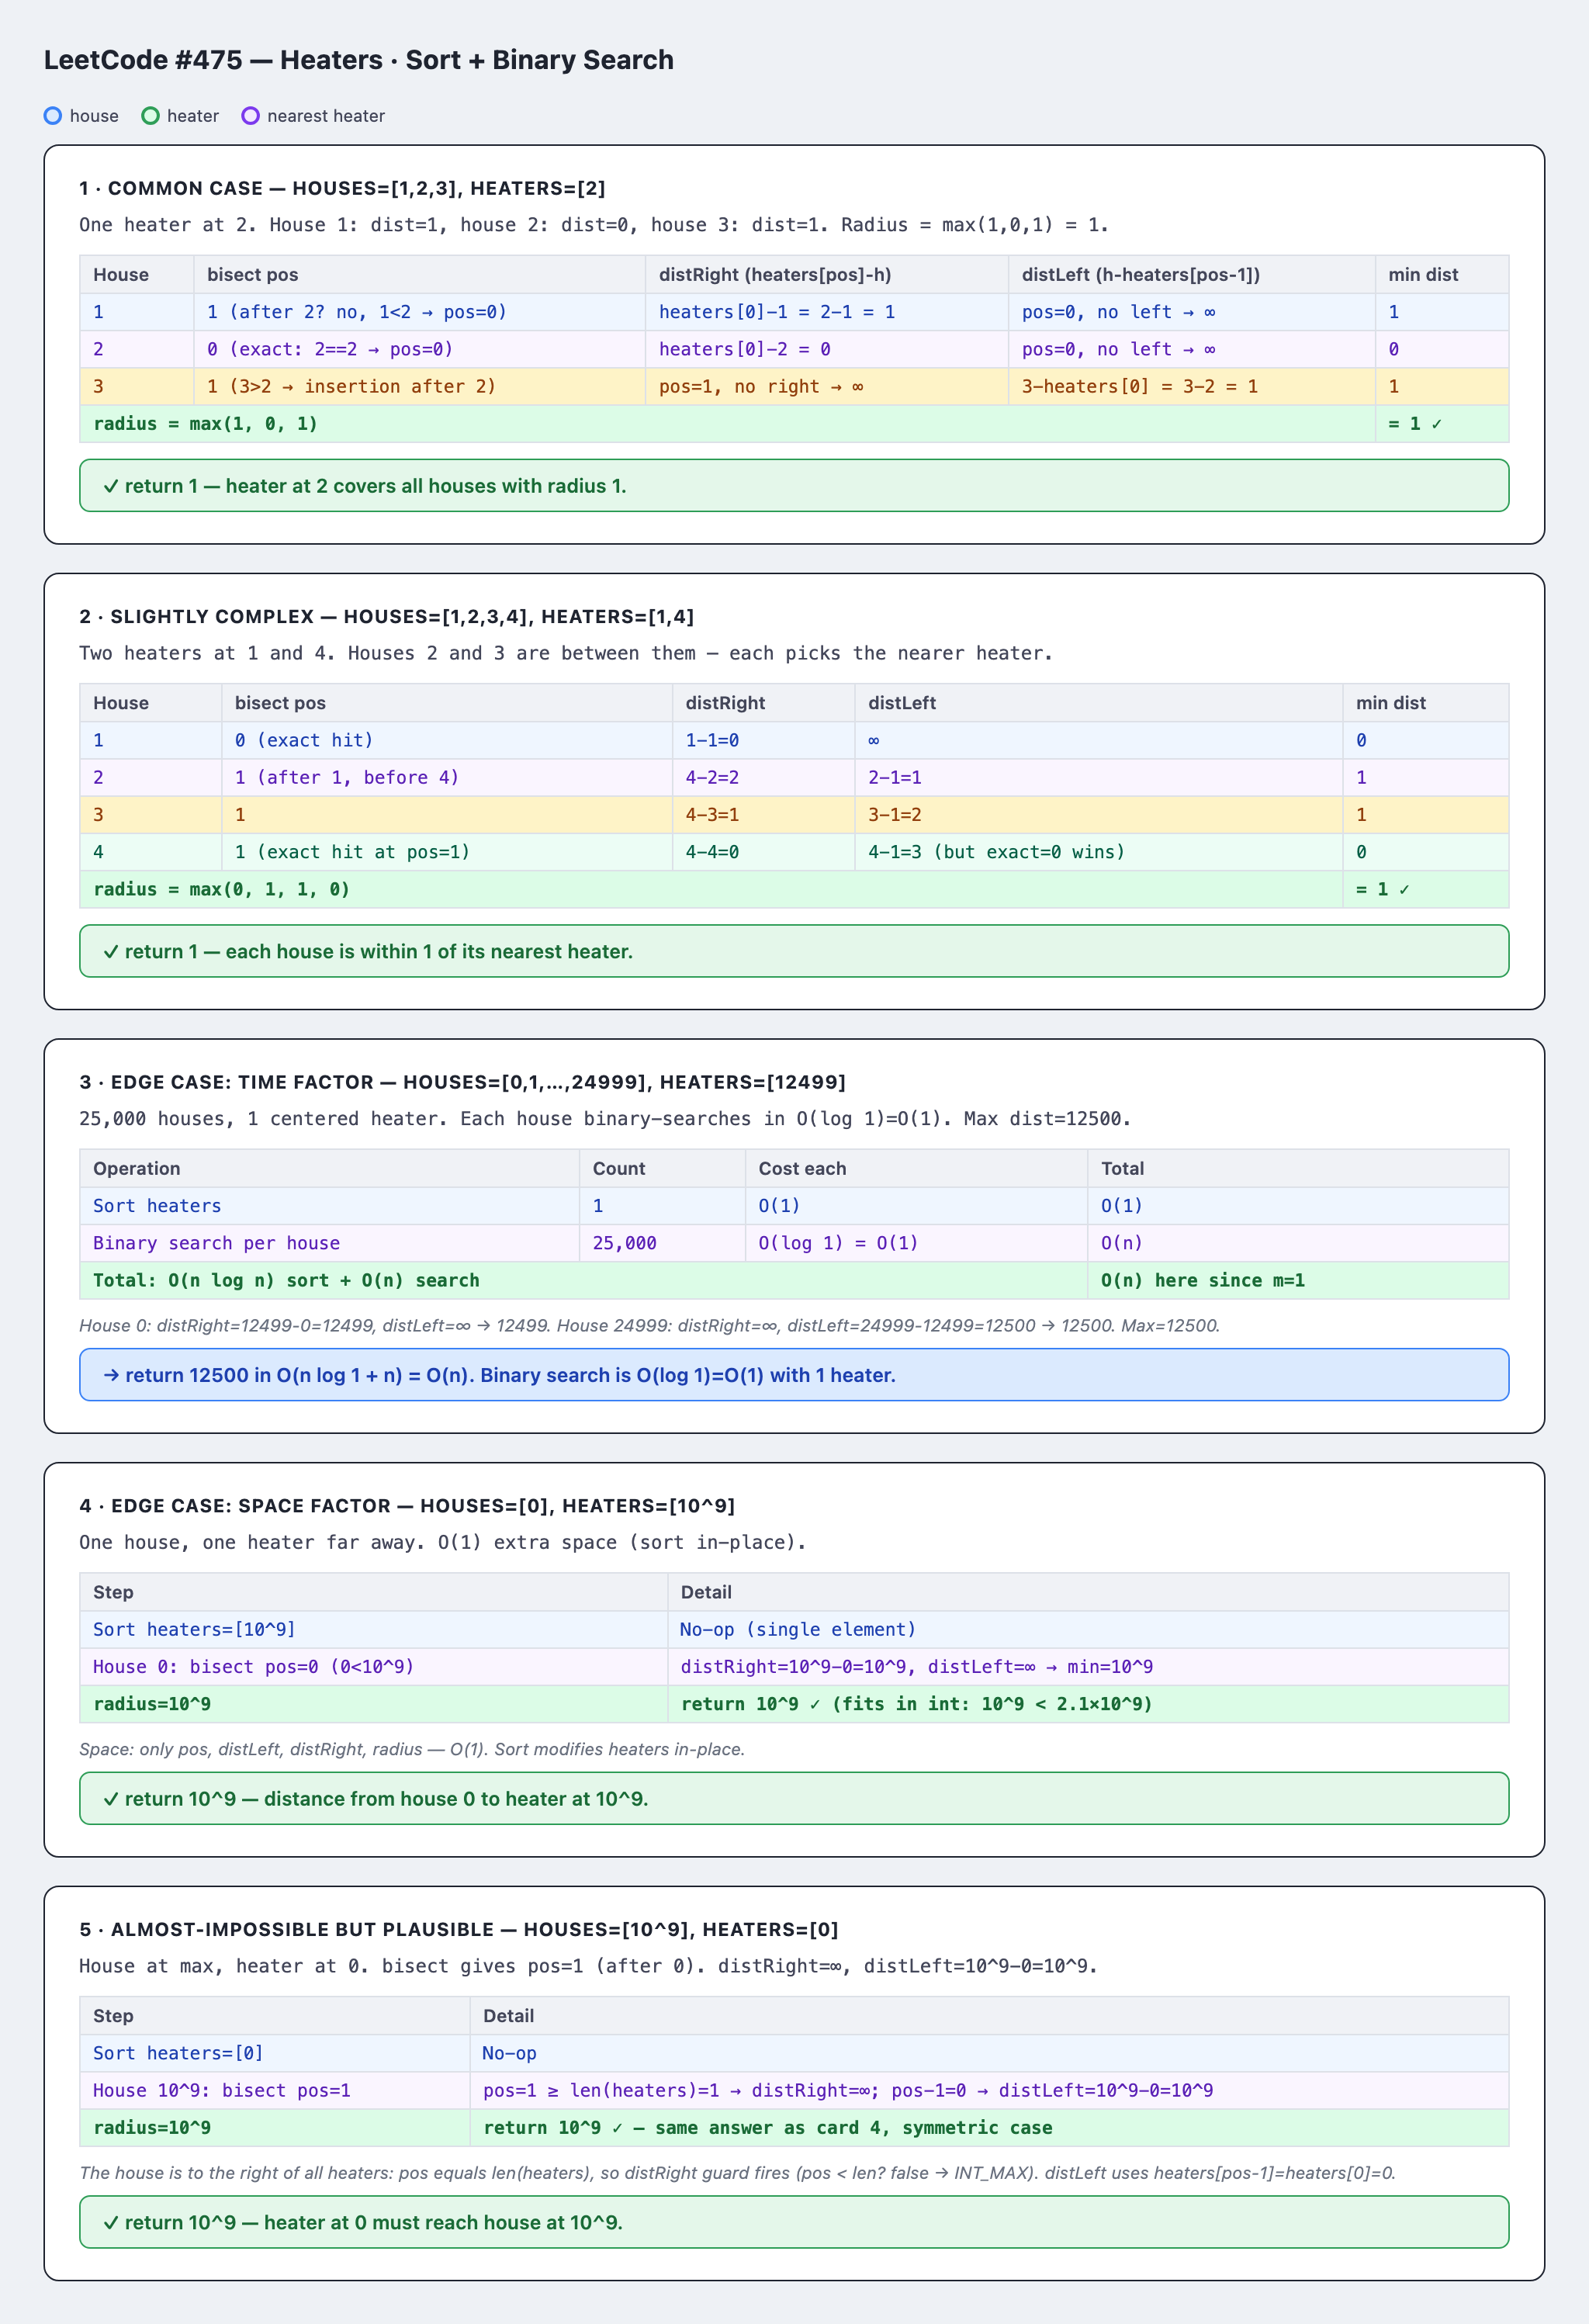